# LACT 电子学链路验证：统一使用 event 1909 / telescope 19

本 notebook 按真实处理顺序排列，所有簇射级图片都使用同一个事例。
只有触发器单元测试和独立 NSB 单元测试使用各自的小型输入，因为它们是在验证
电子学模块能否脱离簇射程序独立运行。

链路为：

`1664 像素相机 → 光收集器 → PDE/通道 gap → primary p.e. →`
`微单元占用饱和 → fired p.e. → 单 p.e. 脉冲 → 4 ns 采样 →`
`pylast 读取 → 触发与独立 NSB 检查`


In [1]:
# Cell 1｜集中设置可修改参数、读取 ROOT，并定义后续共用的相机绘图函数。
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection, PolyCollection
from matplotlib.patches import Rectangle, Polygon
from mpl_toolkits.axes_grid1 import make_axes_locatable

NOTEBOOK_REPO_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (candidate / 'validation' / 'electronics_chain_v2').exists()
    ),
    Path.cwd().resolve(),
)
ROOT_PATH = (
    NOTEBOOK_REPO_ROOT / 'validation' / 'electronics_chain_v2'
    / 'validation_outputs' / 'gamma_e2e' / 'lact_events.root'
)
STANDALONE_ROOT = (
    NOTEBOOK_REPO_ROOT / 'validation' / 'electronics_chain_v2'
    / 'validation_outputs'
)
EVENT_ID = 1909
TELESCOPE_ID = 19
PIXEL_ID = None  # None selects the pixel with the largest saturation loss
N_WAVEFORM_PIXELS = 5
CAMERA_CMAP = 'plasma'
CAMERA_CBAR_MIN = 0.0  # keep zero-valued camera pixels visible
PRIMARY_COLOR = '#2878b5'
FIRED_COLOR = '#f28e2b'
LOST_COLOR = '#d62728'


# S17351 physical-gap / occupancy validation (all editable here)
S17351_GAP_RUN_DIR = STANDALONE_ROOT / 's17351_gap_only'
S17351_PRESATURATION_RUN_DIR = (
    STANDALONE_ROOT / 's17351_channel_gap_pde_conditioned'
)
S17351_SATURATION_RUN_DIR = STANDALONE_ROOT / 's17351_saturation'
S17351_FIGURE_DIR = STANDALONE_ROOT / 's17351_gap_saturation_figures'
S17351_EVENT_ID = 1909
S17351_TELESCOPE_ID = 19
S17351_PIXEL_ID = 832
S17351_SENSOR_SIZE_MM = 13.4
S17351_CHANNEL_SIZE_X_MM = 6.6
S17351_CHANNEL_SIZE_Y_MM = 3.2
S17351_CHANNEL_GAP_MM = 0.2
S17351_MICROCELL_PITCH_MM = 0.025
S17351_ZOOM_HALF_WIDTH_MM = 0.14
S17351_CHANNEL_GAP_COLOR = '#8558a5'
S17351_SATURATION_COLOR = '#c83e4d'
S17351_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# S17351 inter-channel-gap PDE convention A/B (editable here)
S17351_CHANNEL_GAP_PDE_RUN_DIR = (
    STANDALONE_ROOT / 's17351_channel_gap_pde_conditioned'
)
S17351_CHANNEL_GAP_PDE_FIGURE = (
    S17351_FIGURE_DIR / 's17351_channel_gap_pde_comparison.png'
)



# Pre-electronics c75cb18 comparison (all editable here)
PRE_ELECTRONICS_HISTORICAL_DIR = (
    STANDALONE_ROOT / 'pre_electronics_c75cb18'
)
PRE_ELECTRONICS_1664_DIR = (
    STANDALONE_ROOT / 'pre_electronics_c75cb18_camera1664'
)
CURRENT_ELECTRONICS_OFF_DIR = (
    STANDALONE_ROOT / 'current_electronics_disabled'
)
CURRENT_SATURATION_COMPARISON_DIR = (
    STANDALONE_ROOT / 'current_electronics_saturation_comparison'
)
PRE_ELECTRONICS_COMPARISON_DIR = (
    STANDALONE_ROOT / 'pre_electronics_comparison'
)
PRE_ELECTRONICS_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)


# pylast DL0/R1 A/B paths and display choices
PYLAST_RUNTIME_DIR = next(
    candidate
    for candidate in [
        Path('/home/hyy/codex_tmp/pylast_electronics_runtime_20260731'),
        NOTEBOOK_REPO_ROOT.parent / 'pylast_electronics_v2_20260731' / 'src',
    ]
    if (candidate / 'pylast' / '__init__.py').exists()
)
PYLAST_NO_WAVEFORM_ROOT = (
    STANDALONE_ROOT / 's17351_no_waveform' / 'lact_events.root'
)
PYLAST_WAVEFORM_ROOT = (
    STANDALONE_ROOT / 's17351_waveform' / 'lact_events.root'
)
PYLAST_FIGURE_DIR = STANDALONE_ROOT / 'pylast_waveform_modes'
PYLAST_EVENT_ID = 1909
PYLAST_TELESCOPE_ID = 19
PYLAST_N_WAVEFORM_PIXELS = 4
PYLAST_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert ROOT_PATH.exists(), ROOT_PATH
root = uproot.open(ROOT_PATH)
CAMERA_FOCAL_LENGTH_M = float(
    root['optics']['equivalent_focal_length_m']
    .array(library='np')[0]
)
camera = root['camera_pixels'].arrays(library='np')
observations = root['observations'].arrays(library='ak')
waveform_cfg = root['waveform_config'].arrays(library='ak')
waveforms = root['waveforms'].arrays(library='ak')
primary_hits = root['primary_pe_hits'].arrays(library='np')
fired_hits = root['fired_pe_hits'].arrays(library='np')
decisions = root['microcell_decisions'].arrays(library='np')
config_text = str(root['config']['expanded_config_text'].array(library='np')[0])
cfg = dict(line.split('=', 1) for line in config_text.splitlines() if '=' in line)
pixel_to_index = {int(pid): i for i, pid in enumerate(camera['pixel_id'])}

def observation_row(event_id=EVENT_ID, telescope_id=TELESCOPE_ID):
    mask = (np.asarray(observations.event_id) == event_id) & (np.asarray(observations.telescope_id) == telescope_id)
    idx = np.flatnonzero(mask)
    assert len(idx) == 1, (event_id, telescope_id, len(idx))
    return observations[int(idx[0])]

def dense_image(row, field):
    values = np.zeros(len(camera['pixel_id']), dtype=float)
    for pid, value in zip(np.asarray(row.pixel_id), np.asarray(row[field])):
        values[pixel_to_index[int(pid)]] = float(value)
    return values

def pylast_event_camera_image(
    ax,
    pixel_x_m,
    pixel_y_m,
    pixel_size_m,
    values,
    focal_length_m,
    *,
    vmax=None,
    colorbar_label='PE',
    annotation=None,
    add_colorbar=True,
    colorbar_pad=0.6,
    show_secondary_y=True,
):
    """Draw LACT hardware-plane pixels in pylast's sky-offset convention."""
    values = np.asarray(values, dtype=float)
    hardware_x_cm = np.asarray(pixel_x_m, dtype=float) * 100.0
    hardware_y_cm = np.asarray(pixel_y_m, dtype=float) * 100.0
    pixel_size_cm = np.broadcast_to(
        np.asarray(pixel_size_m, dtype=float) * 100.0,
        values.shape,
    )
    assert (
        hardware_x_cm.shape
        == hardware_y_cm.shape
        == pixel_size_cm.shape
        == values.shape
    )

    # Match LactEventSource's hardware -> sky conversion exactly:
    # camera_x=-hardware_y (elevation-like), camera_y=-hardware_x
    # (azimuth-like). EventVisualizer displays camera Y horizontally and
    # camera X vertically.
    camera_x_cm = -hardware_y_cm
    camera_y_cm = -hardware_x_cm
    plot_x = camera_y_cm
    plot_y = camera_x_cm
    x0 = (plot_x - pixel_size_cm / 2)[:, None]
    x1 = (plot_x + pixel_size_cm / 2)[:, None]
    y0 = (plot_y - pixel_size_cm / 2)[:, None]
    y1 = (plot_y + pixel_size_cm / 2)[:, None]
    vertices = np.concatenate(
        [
            np.stack([x0, y0], axis=2),
            np.stack([x0, y1], axis=2),
            np.stack([x1, y1], axis=2),
            np.stack([x1, y0], axis=2),
            np.stack([x0, y0], axis=2),
        ],
        axis=1,
    ).astype(float)

    max_value = max(
        float(np.max(values)) if values.size else 1.0,
        1.0,
    )
    if vmax is not None:
        max_value = max(float(vmax), 1.0)

    # Exact EventVisualizer policy: zero is opaque white, positives use plasma.
    colors = [(1, 1, 1, 1)] + plt.cm.plasma(
        np.linspace(0, 1, 256)
    ).tolist()
    cmap = mcolors.ListedColormap(colors)
    bounds = [0, 1] + np.linspace(1, max_value, 256).tolist()
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    collection = PolyCollection(
        vertices,
        array=values,
        cmap=cmap,
        norm=norm,
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0.2,
        rasterized=True,
    )
    ax.add_collection(collection)

    pad = float(np.max(pixel_size_cm))
    ax.set_xlim(float(plot_x.min() - pad), float(plot_x.max() + pad))
    ax.set_ylim(float(plot_y.min() - pad), float(plot_y.max() + pad))
    ax.set_aspect('equal')
    ax.set_xlabel('Azimuth-like camera Y (cm)')
    ax.set_ylabel('Elevation-like camera X (cm)')

    focal_length_cm = float(focal_length_m) * 100.0
    secondary_x = ax.secondary_xaxis(
        'top',
        functions=(
            lambda x: np.degrees(np.arctan(x / focal_length_cm)),
            lambda deg: np.tan(np.radians(deg)) * focal_length_cm,
        ),
    )
    secondary_x.set_xlabel('Azimuth offset (degrees)')
    if show_secondary_y:
        secondary_y = ax.secondary_yaxis(
            'right',
            functions=(
                lambda y: np.degrees(np.arctan(y / focal_length_cm)),
                lambda deg: np.tan(np.radians(deg)) * focal_length_cm,
            ),
        )
        secondary_y.set_ylabel('Elevation offset (degrees)')

    if annotation:
        ax.text(
            0.05,
            0.96,
            annotation,
            transform=ax.transAxes,
            fontsize=11,
            color='black',
            va='top',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )

    if add_colorbar:
        divider = make_axes_locatable(ax)
        colorbar_axis = divider.append_axes('right', size='5%', pad=colorbar_pad)
        scalar_map = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        scalar_map.set_array([])
        plt.colorbar(
            scalar_map,
            cax=colorbar_axis,
            label=colorbar_label,
        )
    return collection

print(f'ROOT: {ROOT_PATH}')
print(f'camera pixels: {len(camera["pixel_id"])}; event={EVENT_ID}; telescope={TELESCOPE_ID}')
print(f'waveform: {waveform_cfg.waveform_source[0]}, {waveform_cfg.sample_unit[0]}, {waveform_cfg.time_bin_width_ns[0]} ns samples')

S17351_CHANNEL_GAP_PDE_HISTOGRAM = (
    S17351_FIGURE_DIR / 's17351_channel_gap_pde_histogram.png'
)

ROOT: /home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/gamma_e2e/lact_events.root
camera pixels: 1664; event=1909; telescope=19
waveform: electronics, mV, 4.0 ns samples


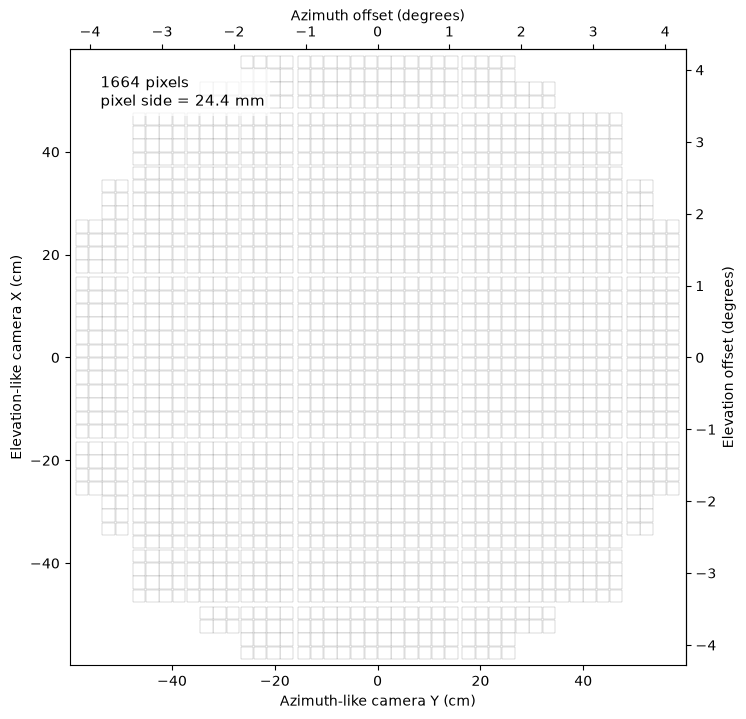

In [2]:
# 本 Cell：只画 1664 像素相机的几何排布，不包含任何光子或 p.e.。
fig, ax = plt.subplots(figsize=(8, 8))
pylast_event_camera_image(
    ax,
    camera['x_m'],
    camera['y_m'],
    camera['size_m'],
    np.zeros(len(camera['pixel_id']), dtype=float),
    CAMERA_FOCAL_LENGTH_M,
    annotation=(
        f'{len(camera["pixel_id"])} pixels\n'
        f'pixel side = {camera["size_m"][0]*1e3:.1f} mm'
    ),
    add_colorbar=False,
)
plt.show()

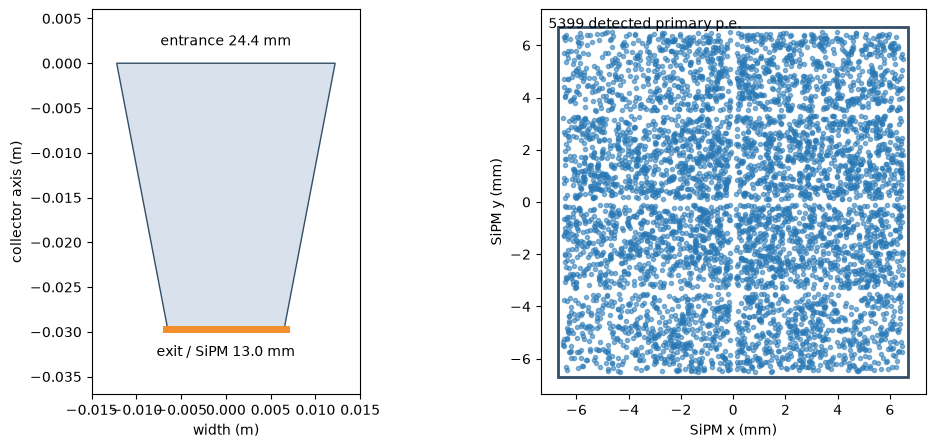

In [3]:
# 本 Cell：画光收集器入口/出口，并显示 event 1909、telescope 19 到达 SiPM 的 primary p.e. 位置。
entrance = float(camera['size_m'][0])
exit_size = float(cfg['camera.collector_exit_size_m'])
height = float(cfg['camera.collector_height_m'])
sensor_x = float(cfg['electronics.microcell.sensor_size_x_m'])
sensor_y = float(cfg['electronics.microcell.sensor_size_y_m'])
mask = (primary_hits['event_id'] == EVENT_ID) & (primary_hits['telescope_id'] == TELESCOPE_ID)
hits = {name: values[mask] for name, values in primary_hits.items()}
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
profile = Polygon([(-entrance/2, 0), (entrance/2, 0), (exit_size/2, -height), (-exit_size/2, -height)], closed=True, facecolor='#d9e2ec', edgecolor='#334e68')
ax0.add_patch(profile); ax0.plot([-sensor_x/2, sensor_x/2], [-height, -height], color=FIRED_COLOR, lw=5)
ax0.text(0, 0.002, f'entrance {entrance*1e3:.1f} mm', ha='center')
ax0.text(0, -height-0.003, f'exit / SiPM {exit_size*1e3:.1f} mm', ha='center')
ax0.set_xlim(-0.015, 0.015); ax0.set_ylim(-0.037, 0.006); ax0.set_aspect('equal'); ax0.set_xlabel('width (m)'); ax0.set_ylabel('collector axis (m)')
ax1.add_patch(Rectangle((-sensor_x/2*1e3, -sensor_y/2*1e3), sensor_x*1e3, sensor_y*1e3, fill=False, lw=2, ec='#334e68'))
ax1.scatter(hits['sensor_x_m']*1e3, hits['sensor_y_m']*1e3, s=9, alpha=0.55, color=PRIMARY_COLOR)
ax1.set_aspect('equal'); ax1.set_xlabel('SiPM x (mm)'); ax1.set_ylabel('SiPM y (mm)')
ax1.text(0.02, 0.98, f'{len(hits["sensor_x_m"])} detected primary p.e.', transform=ax1.transAxes, va='top')
plt.show()

## S17351 几何、通道 gap 与微单元饱和

这一节只检查 SiPM 物理阶段。先读取两次同种子运行，确认开启饱和前后的
primary p.e. 序列完全相同；随后展示 8 通道排布、0.2 mm gap、25 um pitch
索引和同一微单元重复命中。这里没有加入 NSB，也不假设微单元内部 47% 感光区形状。


In [4]:
# 本 Cell：读取默认 PDE/gap 下的饱和关闭与开启两组程序输出，并检查两组 primary 序列完全一致。
def s17351_load_run(folder):
    root_file = uproot.open(folder / 'lact_events.root')
    return {
        'root': root_file,
        'decisions': root_file['microcell_decisions'].arrays(library='pd'),
        'collector': pd.read_csv(folder / 'collector_photons.csv'),
        'camera': root_file['camera_pixels'].arrays(library='np'),
        'observations': root_file['observations'].arrays(library='ak'),
    }

s17351_gap = s17351_load_run(S17351_PRESATURATION_RUN_DIR)
s17351_sat = s17351_load_run(S17351_SATURATION_RUN_DIR)
s17351_identity = [
    'event_id', 'telescope_id', 'pixel_id', 'time_ns',
    'sensor_x_m', 'sensor_y_m', 'grid_column', 'grid_row',
    'channel_id', 'microcell_id', 'origin',
]
assert s17351_gap['decisions'][s17351_identity].equals(
    s17351_sat['decisions'][s17351_identity]
)
assert set(s17351_gap['decisions']['origin'].unique()) == {0}
assert set(s17351_sat['decisions']['origin'].unique()) == {0}

s17351_summary = pd.DataFrame([
    {
        'run': 'default gap/PDE, saturation off',
        'collector candidates': len(s17351_gap['collector']),
        'channel-gap rejected': int(
            s17351_gap['collector']['sipm_channel_gap_rejected'].sum()
        ),
        'primary Cherenkov p.e.': len(s17351_gap['decisions']),
        'fired Cherenkov p.e.': int(
            s17351_gap['decisions']['fired'].sum()
        ),
        'saturation rejected': int(
            s17351_gap['decisions']['saturation_rejected'].sum()
        ),
        'NSB p.e.': int(
            (s17351_gap['decisions']['origin'] != 0).sum()
        ),
    },
    {
        'run': 'default gap/PDE, saturation on',
        'collector candidates': len(s17351_sat['collector']),
        'channel-gap rejected': int(
            s17351_sat['collector']['sipm_channel_gap_rejected'].sum()
        ),
        'primary Cherenkov p.e.': len(s17351_sat['decisions']),
        'fired Cherenkov p.e.': int(
            s17351_sat['decisions']['fired'].sum()
        ),
        'saturation rejected': int(
            s17351_sat['decisions']['saturation_rejected'].sum()
        ),
        'NSB p.e.': int(
            (s17351_sat['decisions']['origin'] != 0).sum()
        ),
    },
])
display(s17351_summary)
print('The primary p.e. sequences are identical; NSB p.e. = 0.')

,run,collector candidates,channel-gap rejected,primary Cherenkov p.e.,fired Cherenkov p.e.,saturation rejected,NSB p.e.
0,"default gap/PDE, saturation off",14487,970,12372,12372,0,0
1,"default gap/PDE, saturation on",14487,970,12372,12367,5,0


The primary p.e. sequences are identical; NSB p.e. = 0.


In [5]:
# 本 Cell：只定义 S17351 排布、25 um pitch 放大和命中标记的绘图函数；本身不产生物理结果。
def s17351_select_pixel(frame):
    return frame[
        (frame['event_id'] == S17351_EVENT_ID)
        & (frame['telescope_id'] == S17351_TELESCOPE_ID)
        & (frame['pixel_id'] == S17351_PIXEL_ID)
    ].copy()

def s17351_draw_device(ax):
    half = 0.5 * S17351_SENSOR_SIZE_MM
    ax.add_patch(Rectangle(
        (-half, -half), S17351_SENSOR_SIZE_MM, S17351_SENSOR_SIZE_MM,
        facecolor='0.91', edgecolor='0.25', linewidth=1.2, zorder=0,
    ))
    for column in range(2):
        for row_bottom in range(4):
            x0 = -half + column * (
                S17351_CHANNEL_SIZE_X_MM + S17351_CHANNEL_GAP_MM
            )
            y0 = -half + row_bottom * (
                S17351_CHANNEL_SIZE_Y_MM + S17351_CHANNEL_GAP_MM
            )
            ax.add_patch(Rectangle(
                (x0, y0),
                S17351_CHANNEL_SIZE_X_MM,
                S17351_CHANNEL_SIZE_Y_MM,
                facecolor='white', edgecolor='0.55',
                linewidth=0.8, zorder=1,
            ))
            row_top = 3 - row_bottom
            label = (
                f'A-{row_top + 1}' if column == 1
                else f'B-{row_top + 1}'
            )
            ax.text(
                x0 + S17351_CHANNEL_SIZE_X_MM / 2,
                y0 + S17351_CHANNEL_SIZE_Y_MM / 2,
                label, ha='center', va='center',
                color='0.72', fontsize=9, zorder=1,
            )
    ax.set_xlim(-half - 0.2, half + 0.2)
    ax.set_ylim(-half - 0.2, half + 0.2)
    ax.set_aspect('equal')
    ax.set_xlabel('SiPM local x (mm)')
    ax.set_ylabel('SiPM local y (mm)')

def s17351_channel_origin(x_mm, y_mm):
    half = 0.5 * S17351_SENSOR_SIZE_MM
    tile_x = S17351_CHANNEL_SIZE_X_MM + S17351_CHANNEL_GAP_MM
    tile_y = S17351_CHANNEL_SIZE_Y_MM + S17351_CHANNEL_GAP_MM
    column = min(1, max(0, int(math.floor((x_mm + half) / tile_x))))
    row = min(3, max(0, int(math.floor((y_mm + half) / tile_y))))
    return -half + column * tile_x, -half + row * tile_y

def s17351_draw_microcell_zoom(ax, center_x_mm, center_y_mm):
    channel_x0, channel_y0 = s17351_channel_origin(
        center_x_mm, center_y_mm
    )
    half_width = S17351_ZOOM_HALF_WIDTH_MM
    x_min, x_max = center_x_mm - half_width, center_x_mm + half_width
    y_min, y_max = center_y_mm - half_width, center_y_mm + half_width
    pitch = S17351_MICROCELL_PITCH_MM
    first_col = max(0, int(math.floor((x_min-channel_x0)/pitch))-1)
    last_col = min(263, int(math.floor((x_max-channel_x0)/pitch))+1)
    first_row = max(0, int(math.floor((y_min-channel_y0)/pitch))-1)
    last_row = min(127, int(math.floor((y_max-channel_y0)/pitch))+1)
    ax.set_facecolor('white')
    for column in range(first_col, last_col + 1):
        for row in range(first_row, last_row + 1):
            cell_x = channel_x0 + column * pitch
            cell_y = channel_y0 + row * pitch
            ax.add_patch(Rectangle(
                (cell_x, cell_y), pitch, pitch,
                facecolor='0.96', edgecolor='0.52',
                linewidth=0.55, zorder=1,
            ))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')
    ax.set_xlabel('SiPM local x (mm)')
    ax.set_ylabel('SiPM local y (mm)')

def s17351_add_gap_points(ax, collector, full=False):
    channel_gap = collector[
        collector['sipm_channel_gap_rejected'] == 1
    ]
    size = 48 if full else 80
    ax.scatter(
        channel_gap['exit_x_m']*1e3,
        channel_gap['exit_y_m']*1e3,
        s=size, marker='s', facecolors='none',
        edgecolors=S17351_CHANNEL_GAP_COLOR, linewidths=1.7,
        label='channel gap rejected', zorder=6,
    )

def s17351_add_decisions(ax, decisions, include_saturation):
    fired = decisions[decisions['fired']]
    ax.scatter(
        fired['sensor_x_m']*1e3, fired['sensor_y_m']*1e3,
        s=30, c=FIRED_COLOR, edgecolors='white', linewidths=0.45,
        label='fired p.e.', zorder=7,
    )
    if include_saturation:
        saturated = decisions[decisions['saturation_rejected']]
        ax.scatter(
            saturated['sensor_x_m']*1e3,
            saturated['sensor_y_m']*1e3,
            s=110, marker='x', c=S17351_SATURATION_COLOR,
            linewidths=2.1, label='saturation rejected', zorder=9,
        )

## PDE 是否已经包含 8 通道 gap：两种解释的 A/B

这里比较同一个 event 1909 / telescope 19。左边把 PDE 理解为通道区域上的值；
右边采用当前默认设置，先按通道面积比例还原，再显式应用 gap。两张相机图使用
相同色标；随后的直方图按非零相机 pixel 比较，蓝色虚线是前者，橙色实线是默认模式。


In [6]:
# 本 Cell：读取 PDE 不含 gap 与默认 PDE 已含 gap 两组输出，只统计 event 1909、telescope 19。
def load_channel_gap_pde_run(folder):
    root_file = uproot.open(folder / 'lact_events.root')
    return {
        'root': root_file,
        'decisions': root_file[
            'microcell_decisions'
        ].arrays(library='pd'),
        'collector': pd.read_csv(
            folder / 'collector_photons.csv'
        ),
        'camera': root_file[
            'camera_pixels'
        ].arrays(library='np'),
        'observations': root_file[
            'observations'
        ].arrays(library='ak'),
    }

pde_gap_direct = load_channel_gap_pde_run(
    S17351_GAP_RUN_DIR
)
pde_gap_conditioned = load_channel_gap_pde_run(
    S17351_CHANNEL_GAP_PDE_RUN_DIR
)
channel_active_fraction = (
    8 * S17351_CHANNEL_SIZE_X_MM * S17351_CHANNEL_SIZE_Y_MM
    / S17351_SENSOR_SIZE_MM**2
)
channel_conditioning_factor = 1 / channel_active_fraction

def selected_rows(frame):
    return frame[
        (frame['event_id'] == S17351_EVENT_ID)
        & (frame['telescope_id'] == S17351_TELESCOPE_ID)
    ]

def channel_gap_pde_row(label, run):
    decisions = selected_rows(run['decisions'])
    collector = selected_rows(run['collector'])
    return {
        'PDE convention': label,
        'event': S17351_EVENT_ID,
        'telescope': S17351_TELESCOPE_ID,
        'primary Cherenkov p.e.': len(decisions),
        'fired Cherenkov p.e.': int(decisions['fired'].sum()),
        'explicit gap rejected': int(
            collector['sipm_channel_gap_rejected'].sum()
        ),
        'saturation rejected': int(
            decisions['saturation_rejected'].sum()
        ),
        'NSB p.e.': int((decisions['origin'] != 0).sum()),
    }

channel_gap_pde_summary = pd.DataFrame([
    channel_gap_pde_row(
        'PDE excludes channel gaps', pde_gap_direct
    ),
    channel_gap_pde_row(
        'PDE includes channel gaps (default)',
        pde_gap_conditioned,
    ),
])
direct_total = int(channel_gap_pde_summary.iloc[0][
    'primary Cherenkov p.e.'
])
conditioned_total = int(channel_gap_pde_summary.iloc[1][
    'primary Cherenkov p.e.'
])
measured_ratio = conditioned_total / direct_total
channel_gap_pde_summary['p.e. ratio to baseline'] = [
    1.0, measured_ratio
]
assert channel_gap_pde_summary['saturation rejected'].sum() == 0
assert channel_gap_pde_summary['NSB p.e.'].sum() == 0
display(channel_gap_pde_summary)
print(
    f'f_channel = {channel_active_fraction:.7f}; '
    f'1/f_channel = {channel_conditioning_factor:.7f}; '
    f'measured ratio = {measured_ratio:.7f}'
)

,PDE convention,event,telescope,primary Cherenkov p.e.,fired Cherenkov p.e.,explicit gap rejected,saturation rejected,NSB p.e.,p.e. ratio to baseline
0,PDE excludes channel gaps,1909,19,5096,5096,397,0,0,1.000000
1,PDE includes channel gaps (default),1909,19,5399,5399,433,0,0,1.059458


f_channel = 0.9409668; 1/f_channel = 1.0627367; measured ratio = 1.0594584


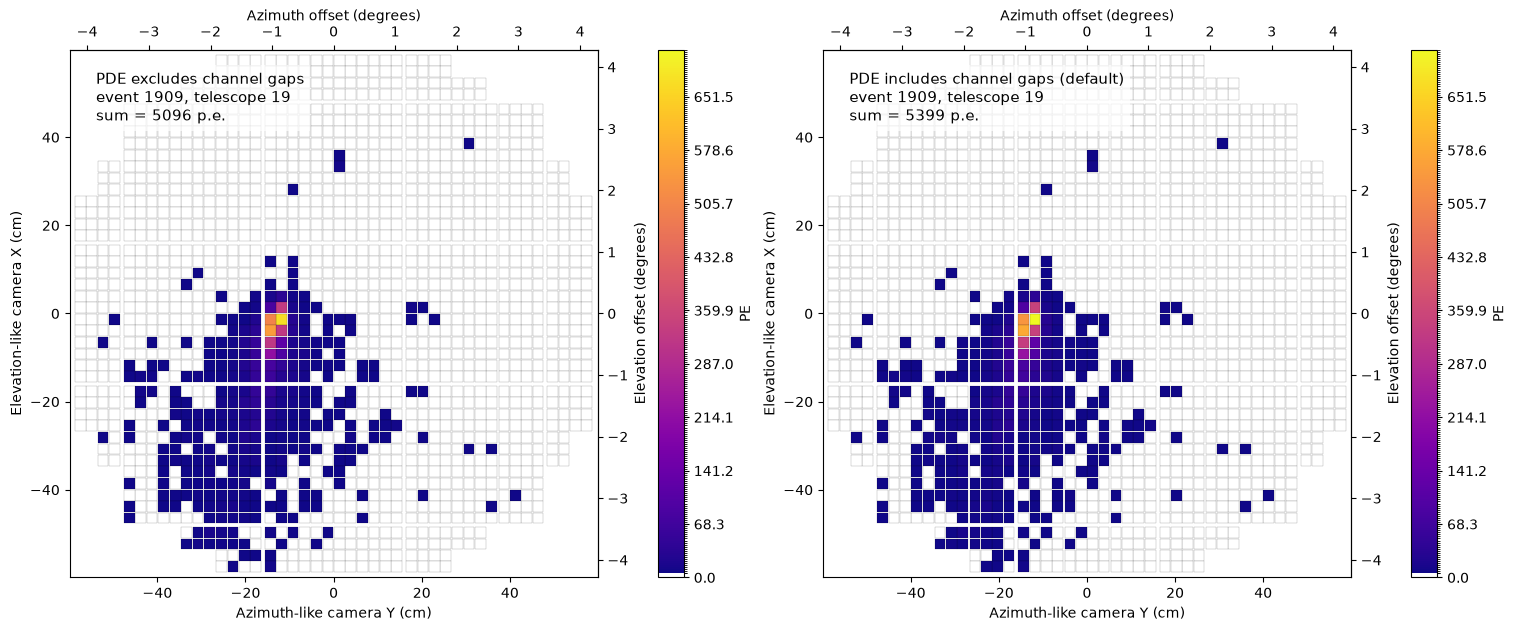

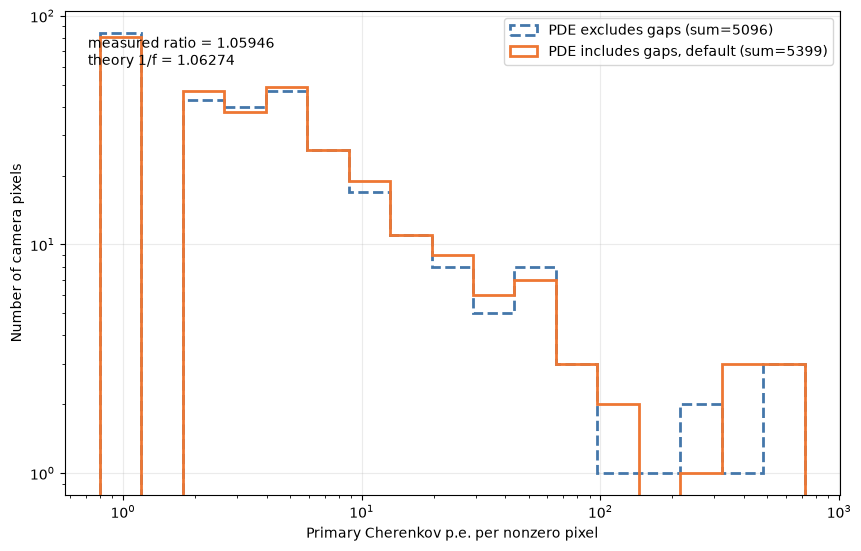

/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_channel_gap_pde_comparison.png
/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_channel_gap_pde_histogram.png


In [7]:
# 本 Cell：先画两张同色标相机 A/B，再画逐 pixel 的虚线/实线 p.e. 直方图。
def selected_primary_camera(run):
    observations = run['observations']
    mask = (
        (np.asarray(observations.event_id) == S17351_EVENT_ID)
        & (np.asarray(observations.telescope_id)
           == S17351_TELESCOPE_ID)
    )
    indices = np.flatnonzero(mask)
    assert len(indices) == 1
    row = observations[int(indices[0])]
    camera_geometry = run['camera']
    pixel_to_index = {
        int(pixel_id): index
        for index, pixel_id in enumerate(
            camera_geometry['pixel_id']
        )
    }
    image = np.zeros(
        len(camera_geometry['pixel_id']), dtype=float
    )
    for pixel_id, value in zip(
        np.asarray(row.pixel_id),
        np.asarray(row.image_cherenkov_pe),
    ):
        image[pixel_to_index[int(pixel_id)]] = float(value)
    return image

direct_camera = selected_primary_camera(pde_gap_direct)
conditioned_camera = selected_primary_camera(
    pde_gap_conditioned
)
pde_camera_geometry = pde_gap_direct['camera']
pde_focal_length_m = float(
    pde_gap_direct['root']['optics'][
        'equivalent_focal_length_m'
    ].array(library='np')[0]
)
shared_vmax = max(
    direct_camera.max(), conditioned_camera.max(), 1.0
)
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6.2), constrained_layout=True
)
for ax, values, label in zip(
    axes[:2],
    [direct_camera, conditioned_camera],
    [
        'PDE excludes channel gaps',
        'PDE includes channel gaps (default)',
    ],
):
    pylast_event_camera_image(
        ax,
        pde_camera_geometry['x_m'],
        pde_camera_geometry['y_m'],
        pde_camera_geometry['size_m'],
        values,
        pde_focal_length_m,
        vmax=shared_vmax,
        colorbar_label='PE',
        annotation=(
            f'{label}\n'
            f'event {S17351_EVENT_ID}, '
            f'telescope {S17351_TELESCOPE_ID}\n'
            f'sum = {values.sum():.0f} p.e.'
        ),
    )

fig.savefig(
    S17351_CHANNEL_GAP_PDE_FIGURE,
    dpi=200,
    bbox_inches='tight',
)
plt.show()

positive_values = np.concatenate([
    direct_camera[direct_camera > 0],
    conditioned_camera[conditioned_camera > 0],
])
pixel_bins = np.geomspace(
    0.8, positive_values.max() + 1.0, 18
)
fig_hist, ax_hist = plt.subplots(
    figsize=(8.5, 5.4), constrained_layout=True
)
ax_hist.hist(
    direct_camera[direct_camera > 0],
    bins=pixel_bins,
    histtype='step', linewidth=2.0, linestyle='--',
    color='#4477aa',
    label=f'PDE excludes gaps (sum={direct_total})',
)
ax_hist.hist(
    conditioned_camera[conditioned_camera > 0],
    bins=pixel_bins,
    histtype='step', linewidth=2.0, linestyle='-',
    color='#ee7733',
    label=(
        f'PDE includes gaps, default '
        f'(sum={conditioned_total})'
    ),
)
ax_hist.set_xscale('log')
ax_hist.set_yscale('log')
ax_hist.set_xlabel('Primary Cherenkov p.e. per nonzero pixel')
ax_hist.set_ylabel('Number of camera pixels')
ax_hist.grid(alpha=.25)
ax_hist.legend()
ax_hist.text(
    .03, .95,
    f'measured ratio = {measured_ratio:.5f}\n'
    f'theory 1/f = {channel_conditioning_factor:.5f}',
    transform=ax_hist.transAxes,
    va='top',
)

fig_hist.savefig(
    S17351_CHANNEL_GAP_PDE_HISTOGRAM,
    dpi=200,
    bbox_inches='tight',
)
plt.show()
print(S17351_CHANNEL_GAP_PDE_FIGURE)
print(S17351_CHANNEL_GAP_PDE_HISTOGRAM)

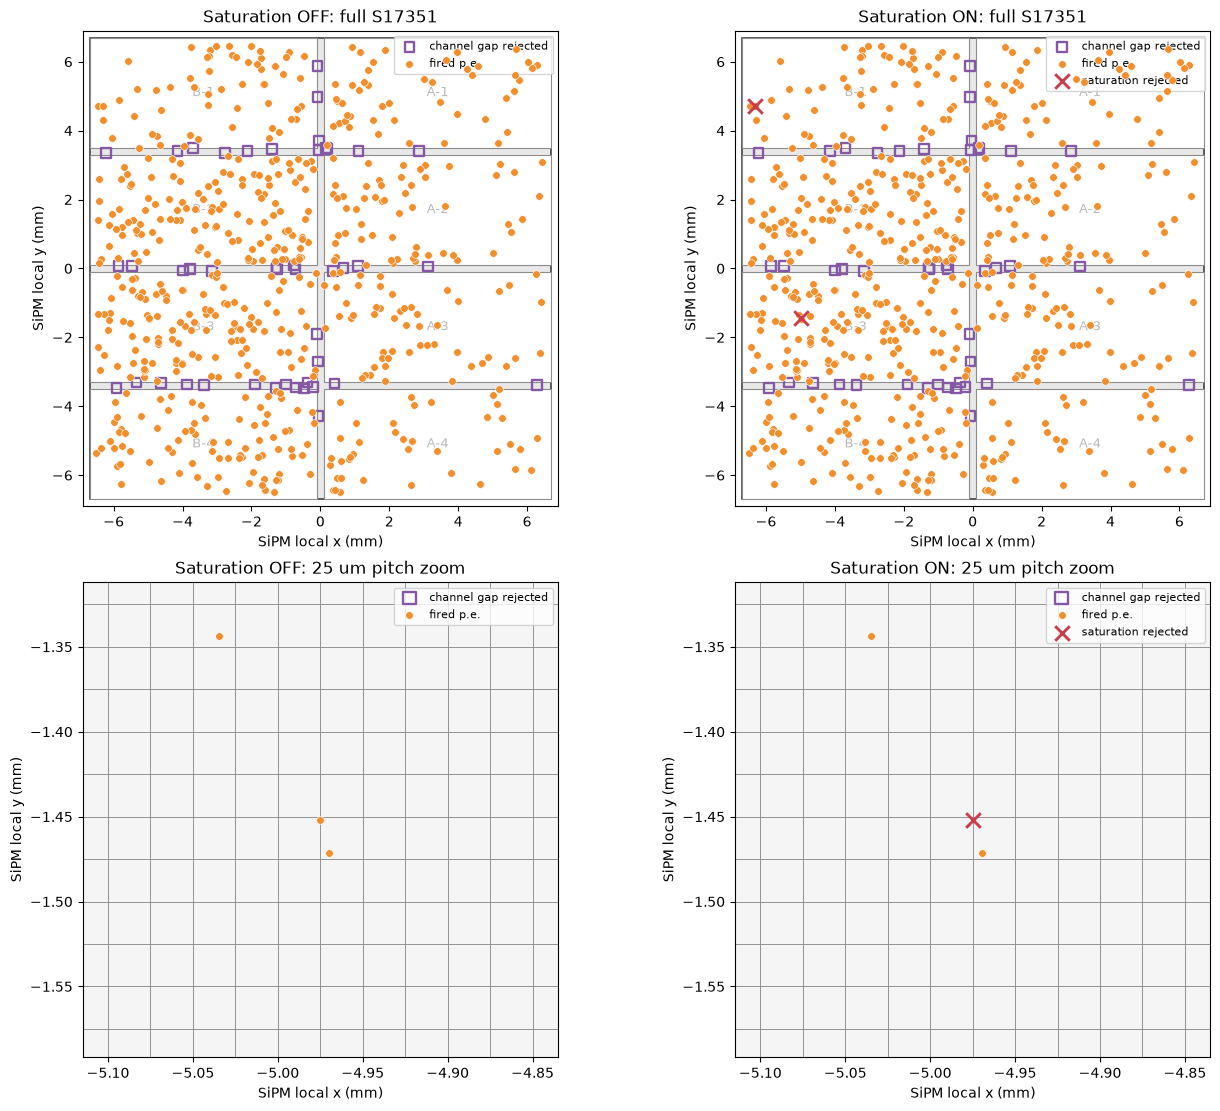

event=1909, telescope=19, pixel=832; primary=576, saturation rejected=2
/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_microcell_saturation_ab.png


In [8]:
# 本 Cell：对同一个有重复命中的 pixel 832 比较“关闭饱和”和“开启饱和”。
# 上排是完整 2x4 通道器件，下排是同一位置的 25 um pitch 放大图。
s17351_gap_decisions = s17351_select_pixel(
    s17351_gap['decisions']
)
s17351_gap_collector = s17351_select_pixel(
    s17351_gap['collector']
)
s17351_sat_decisions = s17351_select_pixel(
    s17351_sat['decisions']
)
s17351_sat_collector = s17351_select_pixel(
    s17351_sat['collector']
)

zoom_rows = s17351_sat_decisions[
    s17351_sat_decisions['saturation_rejected']
]
if len(zoom_rows) == 0:
    zoom_rows = s17351_sat_decisions[
        s17351_sat_decisions['fired']
    ]
assert len(zoom_rows) > 0
zoom_x = float(zoom_rows.iloc[0]['sensor_x_m'] * 1e3)
zoom_y = float(zoom_rows.iloc[0]['sensor_y_m'] * 1e3)

fig, axes = plt.subplots(
    2, 2, figsize=(13, 11), constrained_layout=True
)
modes = [
    (
        s17351_gap_decisions,
        s17351_gap_collector,
        False,
        'Saturation OFF',
    ),
    (
        s17351_sat_decisions,
        s17351_sat_collector,
        True,
        'Saturation ON',
    ),
]
for column, (decision_rows, collector_rows,
             include_saturation, label) in enumerate(modes):
    s17351_draw_device(axes[0, column])
    s17351_add_gap_points(
        axes[0, column], collector_rows, full=True
    )
    s17351_add_decisions(
        axes[0, column], decision_rows, include_saturation
    )
    axes[0, column].set_title(f'{label}: full S17351')
    axes[0, column].legend(loc='upper right', fontsize=8)

    s17351_draw_microcell_zoom(
        axes[1, column], zoom_x, zoom_y
    )
    s17351_add_gap_points(axes[1, column], collector_rows)
    s17351_add_decisions(
        axes[1, column], decision_rows, include_saturation
    )
    axes[1, column].set_title(f'{label}: 25 um pitch zoom')
    axes[1, column].legend(loc='upper right', fontsize=8)

microcell_ab_path = (
    S17351_FIGURE_DIR / 's17351_microcell_saturation_ab.png'
)
fig.savefig(microcell_ab_path, dpi=180, bbox_inches='tight')
plt.show()
print(
    f'event={S17351_EVENT_ID}, telescope={S17351_TELESCOPE_ID}, '
    f'pixel={S17351_PIXEL_ID}; '
    f'primary={len(s17351_sat_decisions)}, '
    f'saturation rejected='
    f'{int(s17351_sat_decisions.saturation_rejected.sum())}'
)
print(microcell_ab_path)

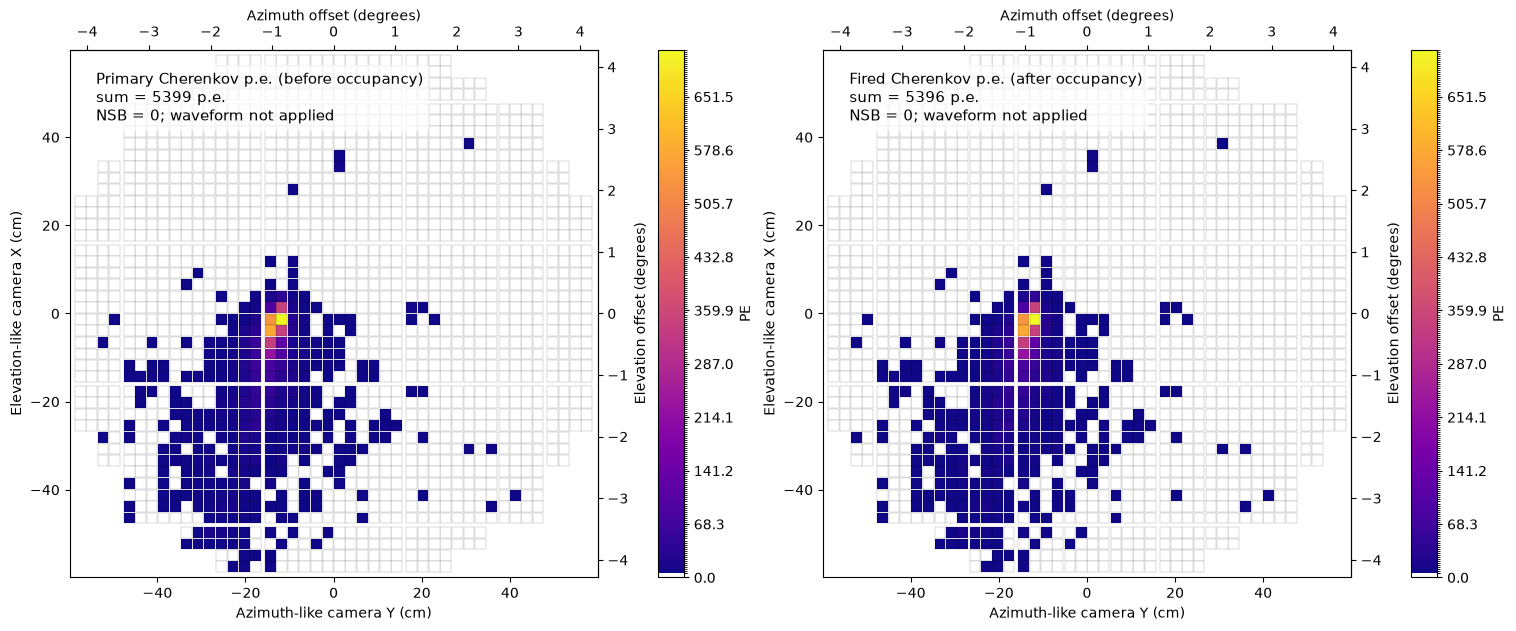

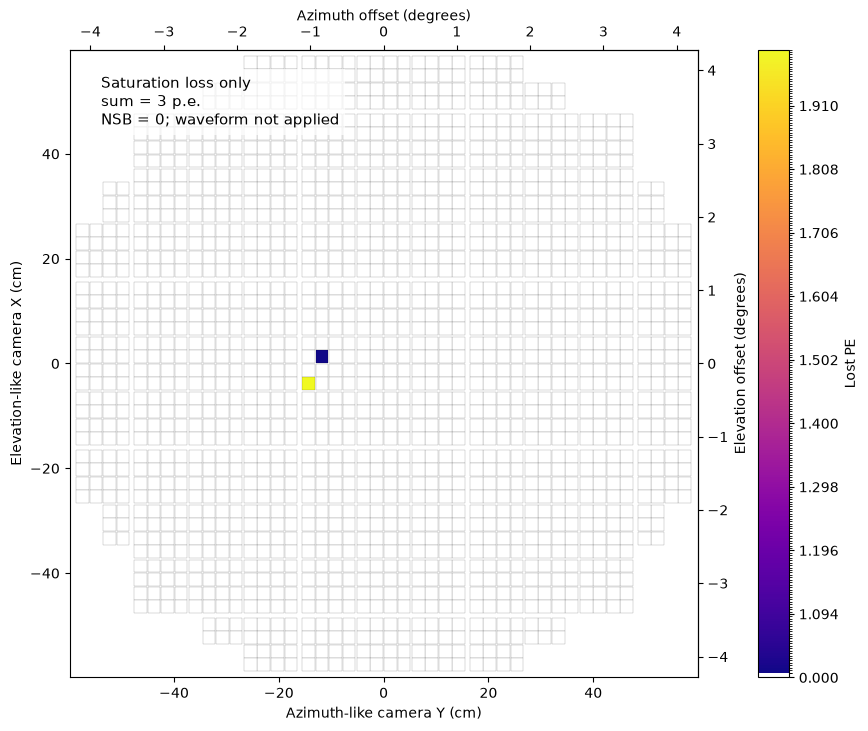

event=1909, telescope=19; primary=5399, fired=5396, saturation loss=3, NSB=0
/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_saturation_only_complete_camera.png
/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_saturation_loss_camera.png


In [9]:
# 本 Cell：画完整相机的饱和前、仅考虑饱和后的 fired 图，以及逐 pixel 饱和损失图；不含 NSB 和波形。
s17351_camera = s17351_sat['camera']
s17351_observations = s17351_sat['observations']
s17351_focal_length_m = float(
    s17351_sat['root']['optics']['equivalent_focal_length_m']
    .array(library='np')[0]
)
camera_mask = (
    (np.asarray(s17351_observations.event_id) == S17351_EVENT_ID)
    & (
        np.asarray(s17351_observations.telescope_id)
        == S17351_TELESCOPE_ID
    )
)
camera_indices = np.flatnonzero(camera_mask)
assert len(camera_indices) == 1
camera_row = s17351_observations[int(camera_indices[0])]
s17351_pixel_to_index = {
    int(pid): i for i, pid in enumerate(s17351_camera['pixel_id'])
}

def s17351_dense_image(row, field):
    values = np.zeros(len(s17351_camera['pixel_id']), dtype=float)
    for pid, value in zip(
        np.asarray(row.pixel_id), np.asarray(row[field])
    ):
        values[s17351_pixel_to_index[int(pid)]] = float(value)
    return values

camera_primary = s17351_dense_image(
    camera_row, 'image_cherenkov_pe'
)
camera_fired = s17351_dense_image(
    camera_row, 'image_fired_cherenkov_pe'
)
camera_nsb = s17351_dense_image(camera_row, 'image_nsb_pe')
assert camera_nsb.sum() == 0
camera_saturation_loss = camera_primary - camera_fired
assert np.all(camera_saturation_loss >= 0)

camera_vmax = max(camera_primary.max(), camera_fired.max(), 1.0)
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6.2), constrained_layout=True
)
labels = [
    'Primary Cherenkov p.e. (before occupancy)',
    'Fired Cherenkov p.e. (after occupancy)',
]
for ax, values, label in zip(
    axes, [camera_primary, camera_fired], labels
):
    pylast_event_camera_image(
        ax,
        s17351_camera['x_m'],
        s17351_camera['y_m'],
        s17351_camera['size_m'],
        values,
        s17351_focal_length_m,
        vmax=camera_vmax,
        colorbar_label='PE',
        annotation=(
            f'{label}\nsum = {values.sum():.0f} p.e.\n'
            'NSB = 0; waveform not applied'
        ),
    )
camera_path = (
    S17351_FIGURE_DIR
    / 's17351_saturation_only_complete_camera.png'
)
fig.savefig(camera_path, dpi=180, bbox_inches='tight')
plt.show()

loss_fig, loss_ax = plt.subplots(
    figsize=(8, 7.2), constrained_layout=True
)
pylast_event_camera_image(
    loss_ax,
    s17351_camera['x_m'],
    s17351_camera['y_m'],
    s17351_camera['size_m'],
    camera_saturation_loss,
    s17351_focal_length_m,
    vmax=max(camera_saturation_loss.max(), 1.0),
    colorbar_label='Lost PE',
    annotation=(
        'Saturation loss only\n'
        f'sum = {camera_saturation_loss.sum():.0f} p.e.\n'
        'NSB = 0; waveform not applied'
    ),
)
camera_loss = camera_saturation_loss.sum()
loss_path = (
    S17351_FIGURE_DIR
    / 's17351_saturation_loss_camera.png'
)
loss_fig.savefig(loss_path, dpi=180, bbox_inches='tight')
plt.show()
print(
    f'event={S17351_EVENT_ID}, telescope={S17351_TELESCOPE_ID}; '
    f'primary={camera_primary.sum():.0f}, '
    f'fired={camera_fired.sum():.0f}, '
    f'saturation loss={camera_loss:.0f}, NSB=0'
)
print(camera_path)
print(loss_path)

## 与未加入电子学的 c75cb18 版本比较

这里固定比较 event 1909、telescope 19，并关闭 NSB 和单 p.e. 波形。历史提交 `c75cb18` 的默认相机是 1616 像素；为了只比较电子学，不把相机边缘新增的 48 个像素混进差值，还额外用同一个旧版二进制和当前 1664 像素相机配置跑了一次公平基准。

因此下面同时保留“历史原样”和“统一为 1664 像素后的公平比较”。真正的微单元饱和损失必须在同一次电子学运行内部用 primary 减 fired；旧版与开启管线后的 primary 差异包含 gap/PDE 条件抽样造成的随机实现变化，不能全部叫作饱和。

In [10]:
# 本 Cell：读取旧版默认 1616、旧版 1664 公平基准、当前电子学关闭和当前饱和四份程序输出，并给出总量表。
def load_comparison_event(folder, fields):
    root_file = uproot.open(folder / 'lact_events.root')
    camera_geometry = root_file['camera_pixels'].arrays(library='np')
    event_rows = root_file['observations'].arrays(library='ak')
    mask = (
        (np.asarray(event_rows.event_id) == EVENT_ID)
        & (np.asarray(event_rows.telescope_id) == TELESCOPE_ID)
    )
    indices = np.flatnonzero(mask)
    assert len(indices) == 1, (folder, EVENT_ID, TELESCOPE_ID, len(indices))
    row = event_rows[int(indices[0])]
    pixel_index = {
        int(pixel_id): index
        for index, pixel_id in enumerate(camera_geometry['pixel_id'])
    }
    images = {}
    for field in fields:
        image = np.zeros(len(camera_geometry['pixel_id']), dtype=float)
        for pixel_id, value in zip(
            np.asarray(row.pixel_id), np.asarray(row[field])
        ):
            image[pixel_index[int(pixel_id)]] = float(value)
        images[field] = image
    return {
        'root': root_file,
        'camera': camera_geometry,
        'images': images,
        'focal_length_m': float(
            root_file['optics']['equivalent_focal_length_m']
            .array(library='np')[0]
        ),
    }

legacy_1616 = load_comparison_event(
    PRE_ELECTRONICS_HISTORICAL_DIR,
    ('image_pe', 'image_cherenkov_pe'),
)
legacy_1664 = load_comparison_event(
    PRE_ELECTRONICS_1664_DIR,
    ('image_pe', 'image_cherenkov_pe'),
)
current_off = load_comparison_event(
    CURRENT_ELECTRONICS_OFF_DIR,
    ('image_pe', 'image_cherenkov_pe'),
)
current_sat = load_comparison_event(
    CURRENT_SATURATION_COMPARISON_DIR,
    ('image_cherenkov_pe', 'image_fired_cherenkov_pe'),
)

legacy_1616_image = legacy_1616['images']['image_cherenkov_pe']
legacy_1664_image = legacy_1664['images']['image_cherenkov_pe']
current_off_image = current_off['images']['image_cherenkov_pe']
current_primary_image = current_sat['images']['image_cherenkov_pe']
current_fired_image = current_sat['images']['image_fired_cherenkov_pe']

assert np.array_equal(
    legacy_1664['camera']['pixel_id'], current_off['camera']['pixel_id']
)
assert np.array_equal(legacy_1664_image, current_off_image)
assert np.array_equal(
    current_off['images']['image_pe'], current_off_image
)
assert np.all(current_fired_image <= current_primary_image)

comparison_table = pd.DataFrame([
    {
        'output': 'c75cb18 historical default',
        'camera pixels': len(legacy_1616_image),
        'quantity': 'legacy Cherenkov p.e.',
        'sum p.e.': legacy_1616_image.sum(),
    },
    {
        'output': 'c75cb18 with current camera',
        'camera pixels': len(legacy_1664_image),
        'quantity': 'legacy Cherenkov p.e.',
        'sum p.e.': legacy_1664_image.sum(),
    },
    {
        'output': 'current, electronics pipeline off',
        'camera pixels': len(current_off_image),
        'quantity': 'legacy-compatible Cherenkov p.e.',
        'sum p.e.': current_off_image.sum(),
    },
    {
        'output': 'current, electronics pipeline on',
        'camera pixels': len(current_primary_image),
        'quantity': 'primary Cherenkov p.e.',
        'sum p.e.': current_primary_image.sum(),
    },
    {
        'output': 'current, electronics pipeline on',
        'camera pixels': len(current_fired_image),
        'quantity': 'fired Cherenkov p.e.',
        'sum p.e.': current_fired_image.sum(),
    },
])
display(comparison_table)
print('1664 fair baseline == current pipeline off: pixel-by-pixel exact')
print(
    'true saturation loss inside the same pipeline run: '
    f'{(current_primary_image-current_fired_image).sum():.0f} p.e.'
)


,output,camera pixels,quantity,sum p.e.
0,c75cb18 historical default,1616,legacy Cherenkov p.e.,5428.0
1,c75cb18 with current camera,1664,legacy Cherenkov p.e.,5452.0
2,"current, electronics pipeline off",1664,legacy-compatible Cherenkov p.e.,5452.0
3,"current, electronics pipeline on",1664,primary Cherenkov p.e.,5399.0
4,"current, electronics pipeline on",1664,fired Cherenkov p.e.,5396.0


1664 fair baseline == current pipeline off: pixel-by-pixel exact
true saturation loss inside the same pipeline run: 3 p.e.


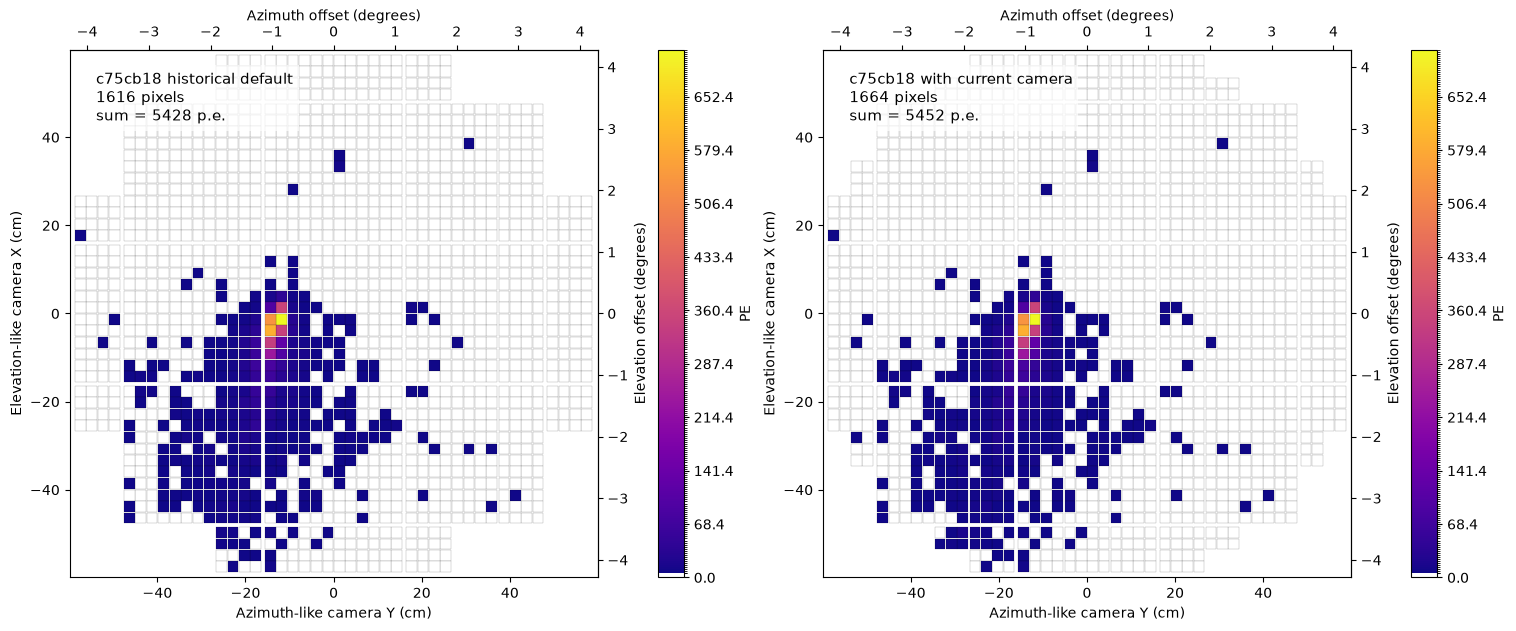

/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/pre_electronics_comparison/historical_1616_vs_1664_camera.png


In [11]:
# 本 Cell：先显示旧版原始 1616 相机和旧版换用 1664 相机的区别；这一步只说明几何变化，不是电子学效应。
historical_vmax = max(
    legacy_1616_image.max(), legacy_1664_image.max(), 1.0
)
historical_fig, historical_axes = plt.subplots(
    1, 2, figsize=(15, 6.2), constrained_layout=True
)
for ax, run, values, annotation in [
    (
        historical_axes[0], legacy_1616, legacy_1616_image,
        'c75cb18 historical default\n1616 pixels\n'
        f'sum = {legacy_1616_image.sum():.0f} p.e.',
    ),
    (
        historical_axes[1], legacy_1664, legacy_1664_image,
        'c75cb18 with current camera\n1664 pixels\n'
        f'sum = {legacy_1664_image.sum():.0f} p.e.',
    ),
]:
    pylast_event_camera_image(
        ax,
        run['camera']['x_m'], run['camera']['y_m'],
        run['camera']['size_m'], values, run['focal_length_m'],
        vmax=historical_vmax,
        colorbar_label='PE',
        annotation=annotation,
    )
historical_path = (
    PRE_ELECTRONICS_COMPARISON_DIR
    / 'historical_1616_vs_1664_camera.png'
)
historical_fig.savefig(historical_path, dpi=180, bbox_inches='tight')
plt.show()
print(historical_path)


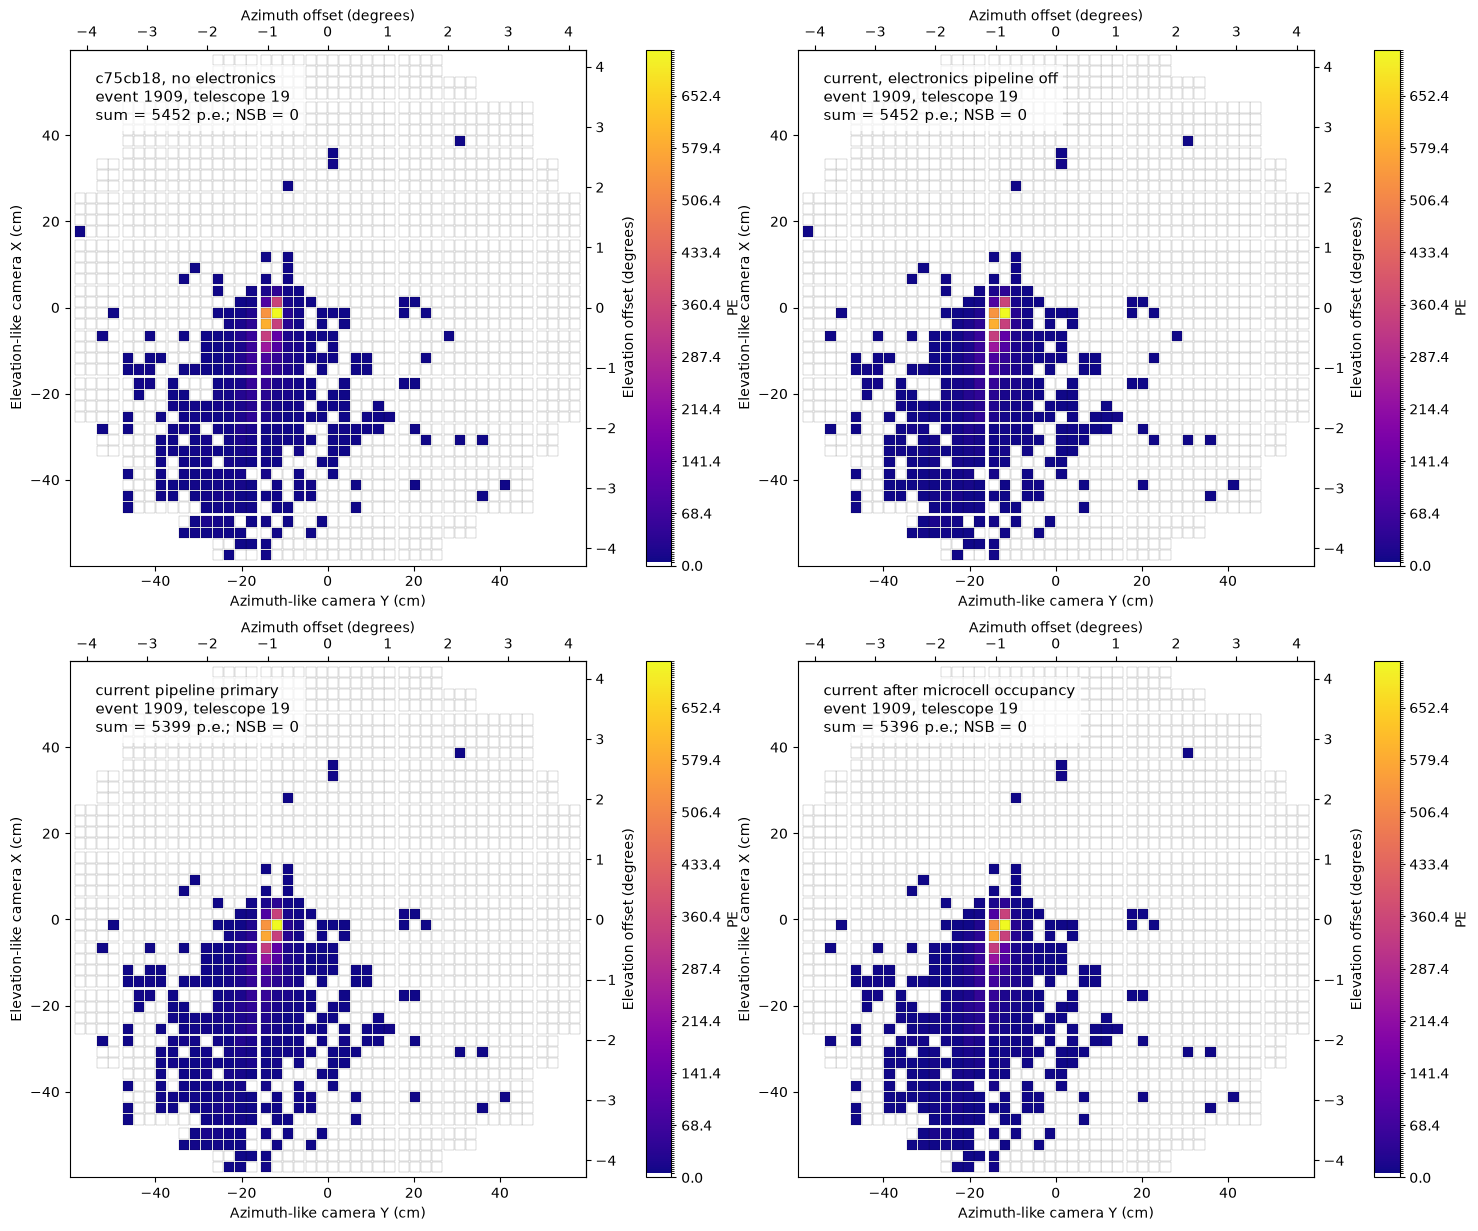

/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/pre_electronics_comparison/legacy_vs_current_electronics_camera.png


In [12]:
# 本 Cell：在完全相同的 1664 像素几何上，依次比较旧版、当前管线关闭、开启管线后的 primary，以及微单元占用后的 fired。
fair_vmax = max(
    legacy_1664_image.max(), current_off_image.max(),
    current_primary_image.max(), current_fired_image.max(), 1.0
)
fair_fig, fair_axes = plt.subplots(
    2, 2, figsize=(14.5, 12.2), constrained_layout=True
)
fair_panels = [
    ('c75cb18, no electronics', legacy_1664_image),
    ('current, electronics pipeline off', current_off_image),
    ('current pipeline primary', current_primary_image),
    ('current after microcell occupancy', current_fired_image),
]
for ax, (label, values) in zip(fair_axes.flat, fair_panels):
    pylast_event_camera_image(
        ax,
        legacy_1664['camera']['x_m'], legacy_1664['camera']['y_m'],
        legacy_1664['camera']['size_m'], values,
        legacy_1664['focal_length_m'],
        vmax=fair_vmax,
        colorbar_label='PE',
        annotation=(
            f'{label}\nevent {EVENT_ID}, telescope {TELESCOPE_ID}\n'
            f'sum = {values.sum():.0f} p.e.; NSB = 0'
        ),
    )
fair_path = (
    PRE_ELECTRONICS_COMPARISON_DIR
    / 'legacy_vs_current_electronics_camera.png'
)
fair_fig.savefig(fair_path, dpi=180, bbox_inches='tight')
plt.show()
print(fair_path)


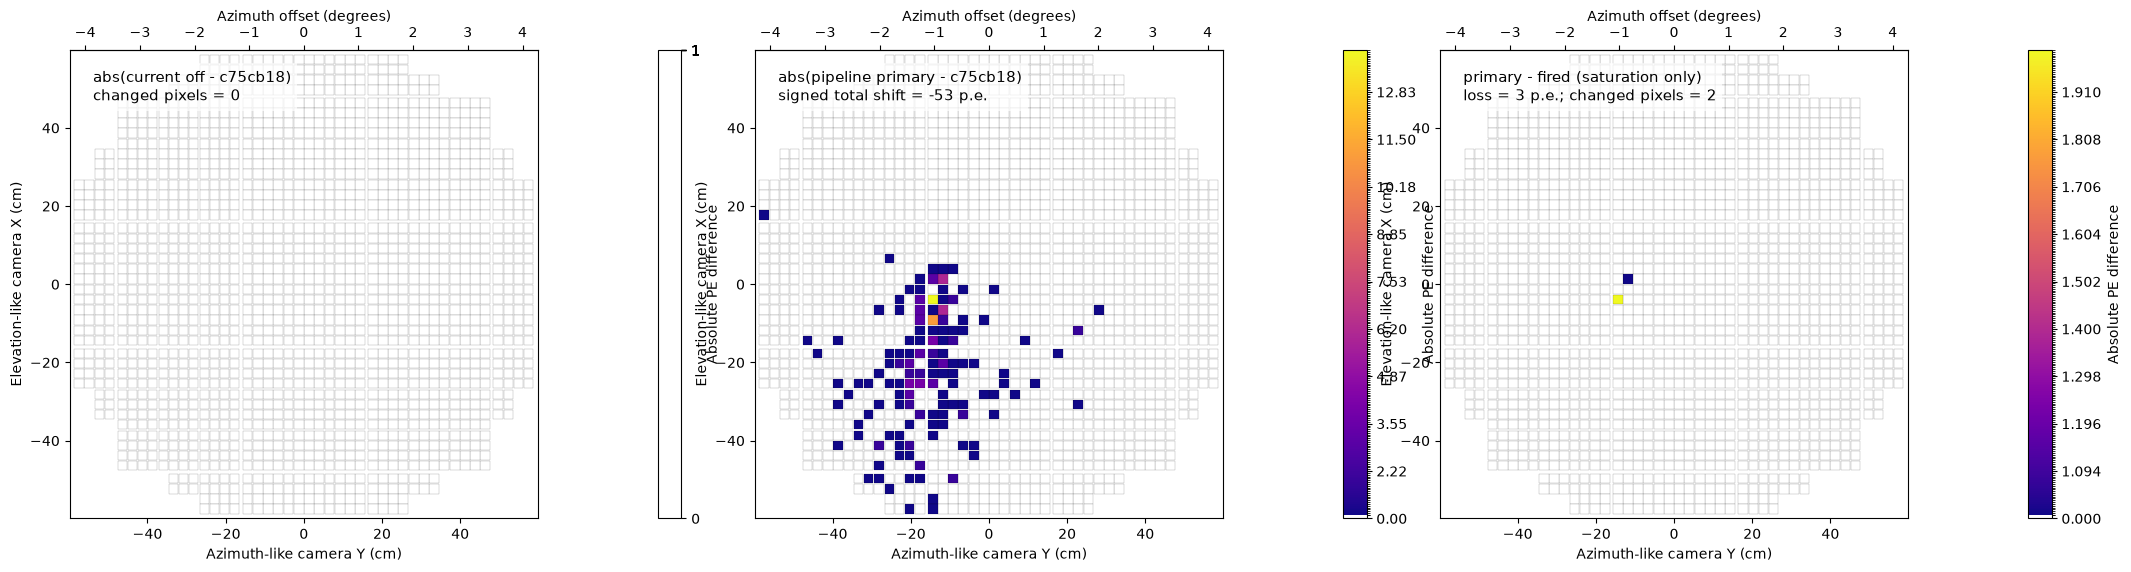

/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/pre_electronics_comparison/legacy_vs_current_difference_cameras.png


In [13]:
# 本 Cell：把三种差值拆开画；左图验证兼容模式为零，中图是管线抽样路径变化，右图才是真正的微单元饱和损失。
off_abs_difference = np.abs(current_off_image - legacy_1664_image)
primary_abs_difference = np.abs(current_primary_image - legacy_1664_image)
saturation_loss_image = current_primary_image - current_fired_image

difference_fig, difference_axes = plt.subplots(
    1, 3, figsize=(20.5, 6.2), constrained_layout=True
)
difference_panels = [
    (
        'abs(current off - c75cb18)', off_abs_difference,
        f'changed pixels = {np.count_nonzero(off_abs_difference)}',
    ),
    (
        'abs(pipeline primary - c75cb18)', primary_abs_difference,
        f'signed total shift = {(current_primary_image-legacy_1664_image).sum():.0f} p.e.',
    ),
    (
        'primary - fired (saturation only)', saturation_loss_image,
        f'loss = {saturation_loss_image.sum():.0f} p.e.; '
        f'changed pixels = {np.count_nonzero(saturation_loss_image)}',
    ),
]
for ax, (label, values, detail) in zip(
    difference_axes, difference_panels
):
    pylast_event_camera_image(
        ax,
        legacy_1664['camera']['x_m'], legacy_1664['camera']['y_m'],
        legacy_1664['camera']['size_m'], values,
        legacy_1664['focal_length_m'],
        vmax=max(values.max(), 1.0),
        colorbar_label='Absolute PE difference',
        annotation=f'{label}\n{detail}',
        colorbar_pad=1.2,
        show_secondary_y=False,
    )
difference_path = (
    PRE_ELECTRONICS_COMPARISON_DIR
    / 'legacy_vs_current_difference_cameras.png'
)
difference_fig.savefig(
    difference_path, dpi=180, bbox_inches='tight'
)
plt.show()
print(difference_path)


sample spacing = 4.0 ns; samples per pixel = 30


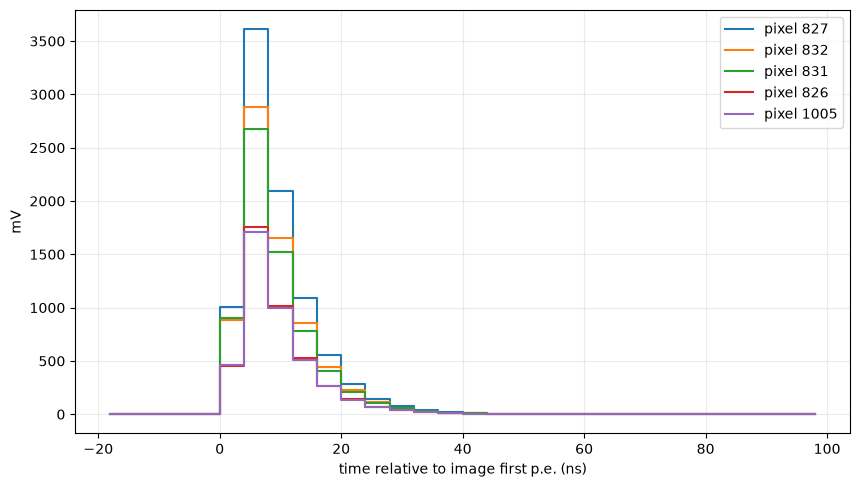

In [14]:
# 本 Cell：直接读取 LACT_sim ROOT 中的 4 ns 采样波形，展示信号最大的几个 pixel；尚未经过 pylast。
wmask = (np.asarray(waveforms.event_id) == EVENT_ID) & (np.asarray(waveforms.telescope_id) == TELESCOPE_ID)
widx = int(np.flatnonzero(wmask)[0]); wrow = waveforms[widx]
times = np.asarray(waveform_cfg.time_centers_ns[0], dtype=float)
dense_wf = np.zeros((len(camera['pixel_id']), len(times)), dtype=float)
for pid, tb, value in zip(np.asarray(wrow.pixel_id), np.asarray(wrow.time_bin), np.asarray(wrow.sample_value)):
    dense_wf[pixel_to_index[int(pid)], int(tb)] += float(value)
top = np.argsort(dense_wf.max(axis=1))[-N_WAVEFORM_PIXELS:][::-1]
fig, ax = plt.subplots(figsize=(10, 5.5))
for idx in top:
    ax.step(times, dense_wf[idx], where='mid', label=f'pixel {camera["pixel_id"][idx]}')
ax.set_xlabel('time relative to image first p.e. (ns)'); ax.set_ylabel(str(waveform_cfg.sample_unit[0])); ax.grid(alpha=.25); ax.legend()
print(f'sample spacing = {np.diff(times)[0]:.1f} ns; samples per pixel = {len(times)}')
plt.show()

## pylast 接口验证：固定 event 1909 / telescope 19

无波形文件的 DL0 只包含通过 p.e. 触发的望远镜，因此 telescope 19 不在该
DL0 集合里。本节从无波形和有波形文件各自的
`simulation.fired_image` 读取 telescope 19 的饱和后真值，并确认二者一致；
随后只从有波形文件读取 telescope 19 的 R1 波形。

所有整相机图统一采用 pylast 的天空偏移坐标：LACT 硬件面坐标先转换为
`camera_x=-hardware_y`、`camera_y=-hardware_x`，然后横轴画 camera Y、纵轴画
camera X。这样 ROOT 直接绘图和 pylast `EventVisualizer` 的热点位置完全一致。

In [15]:
# 本 Cell：固定读取 event 1909、telescope 19 的两份 simulation truth 和有波形 R1；缺失时直接报错。
import importlib
import importlib.util
import sys

def load_pylast_package(package_root):
    package_root = Path(package_root)
    if package_root.exists():
        package_dir = package_root / 'pylast'
        for name in list(sys.modules):
            if name == 'pylast' or name.startswith('pylast.'):
                del sys.modules[name]
        sys.path.insert(0, str(package_root))
        package_spec = importlib.util.spec_from_file_location(
            'pylast',
            package_dir / '__init__.py',
            submodule_search_locations=[str(package_dir)],
        )
        package = importlib.util.module_from_spec(package_spec)
        sys.modules['pylast'] = package
        package_spec.loader.exec_module(package)

        reader_spec = importlib.util.spec_from_file_location(
            'pylast.io.LactEventSource',
            package_dir / 'io' / 'LactEventSource.py',
        )
        reader_module = importlib.util.module_from_spec(reader_spec)
        sys.modules[reader_spec.name] = reader_module
        reader_spec.loader.exec_module(reader_module)

        visualize_dir = package_dir / 'visualize'
        visualize_package_spec = importlib.util.spec_from_file_location(
            'pylast.visualize',
            visualize_dir / '__init__.py',
            submodule_search_locations=[str(visualize_dir)],
        )
        visualize_package = importlib.util.module_from_spec(
            visualize_package_spec
        )
        sys.modules['pylast.visualize'] = visualize_package

        background_spec = importlib.util.spec_from_file_location(
            'pylast.visualize.lhaaso_background',
            visualize_dir / 'lhaaso_background.py',
        )
        background_module = importlib.util.module_from_spec(
            background_spec
        )
        sys.modules[background_spec.name] = background_module
        background_spec.loader.exec_module(background_module)

        event_visualizer_spec = importlib.util.spec_from_file_location(
            'pylast.visualize.event_visualizer',
            visualize_dir / 'event_visualizer.py',
        )
        event_visualizer_module = importlib.util.module_from_spec(
            event_visualizer_spec
        )
        sys.modules[event_visualizer_spec.name] = event_visualizer_module
        event_visualizer_spec.loader.exec_module(event_visualizer_module)
    else:
        import pylast as package
        from pylast.io import LactEventSource as reader_class
        event_visualizer_module = importlib.import_module(
            'pylast.visualize.event_visualizer'
        )
        return package, reader_class, event_visualizer_module.EventVisualizer

    return (
        package,
        reader_module.LactEventSource,
        event_visualizer_module.EventVisualizer,
    )

pylast_package, LactEventSource, EventVisualizer = (
    load_pylast_package(PYLAST_RUNTIME_DIR)
)

def pylast_select_event(source, event_id):
    for index in range(len(source)):
        event = source[index]
        if int(event.event_id) == event_id:
            return event
    raise RuntimeError(f'event {event_id} is not present')

pylast_no_wave_source = LactEventSource(
    str(PYLAST_NO_WAVEFORM_ROOT), max_events=-1
)
pylast_wave_source = LactEventSource(
    str(PYLAST_WAVEFORM_ROOT), max_events=-1
)
pylast_no_wave_event = pylast_select_event(
    pylast_no_wave_source, PYLAST_EVENT_ID
)
pylast_wave_event = pylast_select_event(
    pylast_wave_source, PYLAST_EVENT_ID
)
common_telescopes = sorted(
    set(pylast_no_wave_event.simulation.tels)
    & set(pylast_wave_event.simulation.tels)
    & set(pylast_wave_event.r1.tels)
)
if PYLAST_TELESCOPE_ID not in common_telescopes:
    raise RuntimeError(
        f'requested telescope {PYLAST_TELESCOPE_ID} is not available '
        f'in matched simulation/R1 outputs: {common_telescopes}'
    )
pylast_telescope_id = int(PYLAST_TELESCOPE_ID)

pylast_no_wave_image = np.asarray(
    pylast_no_wave_event.simulation.tels[
        pylast_telescope_id
    ].fired_image,
    dtype=float,
)
pylast_wave_fired_image = np.asarray(
    pylast_wave_event.simulation.tels[
        pylast_telescope_id
    ].fired_image,
    dtype=float,
)
pylast_r1_waveform = np.asarray(
    pylast_wave_event.r1.tels[pylast_telescope_id].waveform,
    dtype=float,
)
pylast_timing = pylast_wave_source.get_waveform_timing(
    pylast_wave_event, pylast_telescope_id
)
pylast_time_ns = np.asarray(
    pylast_timing['time_centers_ns'], dtype=float
)
pylast_sample_width_ns = float(np.median(np.diff(pylast_time_ns)))

assert np.array_equal(
    pylast_no_wave_image, pylast_wave_fired_image
)
assert pylast_r1_waveform.shape == (
    pylast_no_wave_image.size, pylast_time_ns.size
)
print('pylast:', Path(pylast_package.__file__).resolve())
print(
    'EventVisualizer:',
    Path(sys.modules[EventVisualizer.__module__].__file__).resolve(),
)
print(
    f'event={PYLAST_EVENT_ID}, telescope={pylast_telescope_id}; '
    f'no-wave truth={pylast_no_wave_image.sum():.0f} p.e.; '
    f'R1 shape={pylast_r1_waveform.shape}; '
    f'{pylast_sample_width_ns:.1f} ns; '
    f'unit={pylast_timing["sample_unit"]}'
)

pylast: /home/hyy/codex_tmp/pylast_electronics_runtime_20260731/pylast/__init__.py
EventVisualizer: /home/hyy/codex_tmp/pylast_electronics_runtime_20260731/pylast/visualize/event_visualizer.py
event=1909, telescope=19; no-wave truth=5396 p.e.; R1 shape=(1664, 30); 4.0 ns; unit=mV


camera orientation check: ROOT panels and pylast EventVisualizer use identical pixel positions and fired-image values


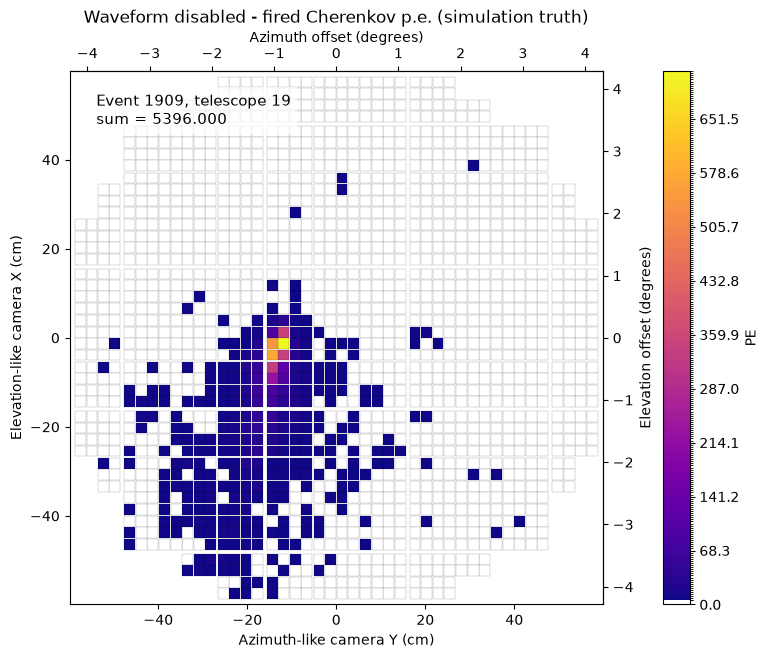

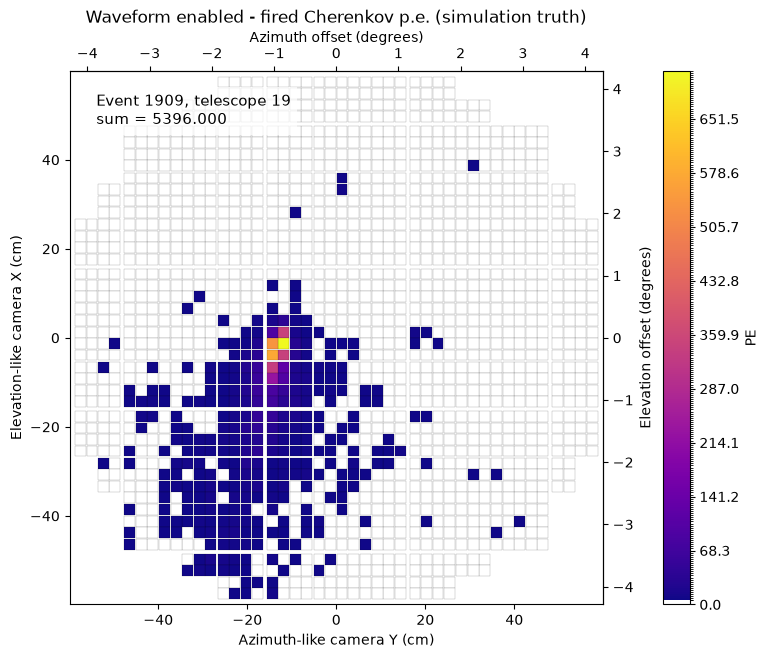

Both p.e. panels use pylast EventVisualizer._image_norm and EventVisualizer._draw_camera_image.


In [16]:
# 本 Cell：用相同像素值检查 ROOT 相机图和 pylast 原生 EventVisualizer 的方向完全一致。
pylast_event_visualizer = EventVisualizer(
    pylast_no_wave_source
)
pylast_telescope_geometry = (
    pylast_event_visualizer.tel_geoms[pylast_telescope_id]
)
expected_plot_x_cm = -np.asarray(camera['x_m'], dtype=float) * 100.0
expected_plot_y_cm = -np.asarray(camera['y_m'], dtype=float) * 100.0
assert np.allclose(
    pylast_telescope_geometry.pix_y, expected_plot_x_cm
)
assert np.allclose(
    pylast_telescope_geometry.pix_x, expected_plot_y_cm
)
assert np.array_equal(camera_fired, pylast_no_wave_image)
print(
    'camera orientation check: ROOT panels and pylast EventVisualizer '
    'use identical pixel positions and fired-image values'
)

def show_pylast_event_camera(
    image,
    title,
    output_name,
    colorbar_label,
):
    fig, axis = plt.subplots(figsize=(8, 8))
    norm, cmap = pylast_event_visualizer._image_norm(image)
    pylast_event_visualizer._draw_camera_image(
        axis,
        pylast_telescope_geometry,
        image,
        norm,
        cmap,
    )
    axis.figure.axes[-1].set_ylabel(colorbar_label)
    axis.set_title(title)
    axis.text(
        0.05,
        0.96,
        f'Event {PYLAST_EVENT_ID}, telescope {pylast_telescope_id}\n'
        f'sum = {image.sum():.3f}',
        transform=axis.transAxes,
        fontsize=11,
        color='black',
        va='top',
        ha='left',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    path = PYLAST_FIGURE_DIR / output_name
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return path

pylast_no_wave_path = show_pylast_event_camera(
    pylast_no_wave_image,
    'Waveform disabled - fired Cherenkov p.e. (simulation truth)',
    'pylast_no_waveform_fired_pe.png',
    'PE',
)
pylast_wave_pe_path = show_pylast_event_camera(
    pylast_wave_fired_image,
    'Waveform enabled - fired Cherenkov p.e. (simulation truth)',
    'pylast_waveform_enabled_fired_pe.png',
    'PE',
)
print(
    'Both p.e. panels use pylast EventVisualizer._image_norm '
    'and EventVisualizer._draw_camera_image.'
)

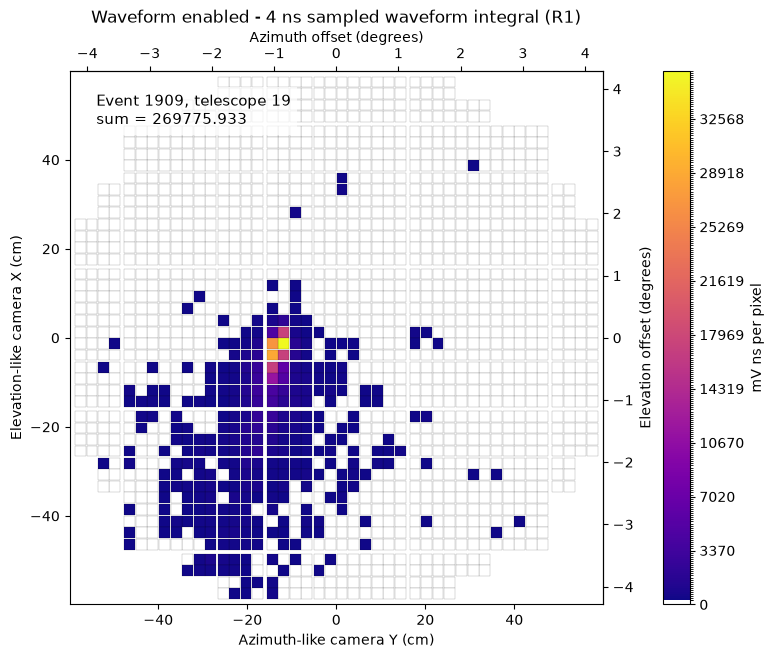

In [17]:
# 本 Cell：对 pylast 读出的 4 ns R1 波形积分，并按相机 pixel 画积分图；单位不再是 p.e.。
pylast_waveform_integral = (
    pylast_r1_waveform.sum(axis=1) * pylast_sample_width_ns
)
pylast_integral_path = show_pylast_event_camera(
    pylast_waveform_integral,
    'Waveform enabled - 4 ns sampled waveform integral (R1)',
    'pylast_waveform_integral.png',
    f'{pylast_timing["sample_unit"]} ns per pixel',
)

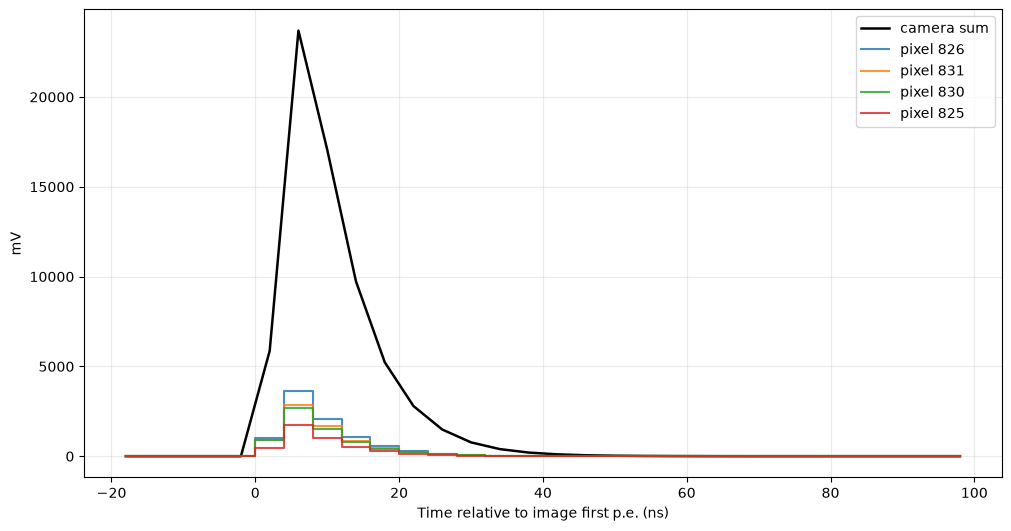

,event_id,telescope_id,camera pixels,no-waveform truth fired p.e.,waveform-on fired p.e.,p.e. images identical,R1 samples per pixel,sample width (ns),sample unit,waveform source
0,1909,19,1664,5396.0,5396.0,True,30,4.0,mV,electronics


In [18]:
# 本 Cell：画 pylast 读出的相机总波形和最强 pixel 波形，并输出无波形/有波形一致性表。
pylast_top_pixels = np.argsort(
    pylast_waveform_integral
)[-PYLAST_N_WAVEFORM_PIXELS:][::-1]
fig, ax = plt.subplots(
    figsize=(10, 5.2), constrained_layout=True
)
ax.plot(
    pylast_time_ns,
    pylast_r1_waveform.sum(axis=0),
    color='black', linewidth=1.8, label='camera sum',
)
for pixel_index in pylast_top_pixels:
    ax.step(
        pylast_time_ns,
        pylast_r1_waveform[pixel_index],
        where='mid',
        label=f'pixel {int(pixel_index)}',
        alpha=.82,
    )
ax.set_xlabel('Time relative to image first p.e. (ns)')
ax.set_ylabel(pylast_timing['sample_unit'])
ax.grid(alpha=.25)
ax.legend()
pylast_trace_path = (
    PYLAST_FIGURE_DIR / 'pylast_r1_waveforms.png'
)
fig.savefig(pylast_trace_path, dpi=200, bbox_inches='tight')
plt.show()

pylast_mode_summary = pd.DataFrame([
    {
        'event_id': PYLAST_EVENT_ID,
        'telescope_id': pylast_telescope_id,
        'camera pixels': pylast_no_wave_image.size,
        'no-waveform truth fired p.e.': pylast_no_wave_image.sum(),
        'waveform-on fired p.e.': pylast_wave_fired_image.sum(),
        'p.e. images identical': np.array_equal(
            pylast_no_wave_image, pylast_wave_fired_image
        ),
        'R1 samples per pixel': pylast_r1_waveform.shape[1],
        'sample width (ns)': pylast_sample_width_ns,
        'sample unit': pylast_timing['sample_unit'],
        'waveform source': pylast_timing['waveform_source'],
    }
])
display(pylast_mode_summary)

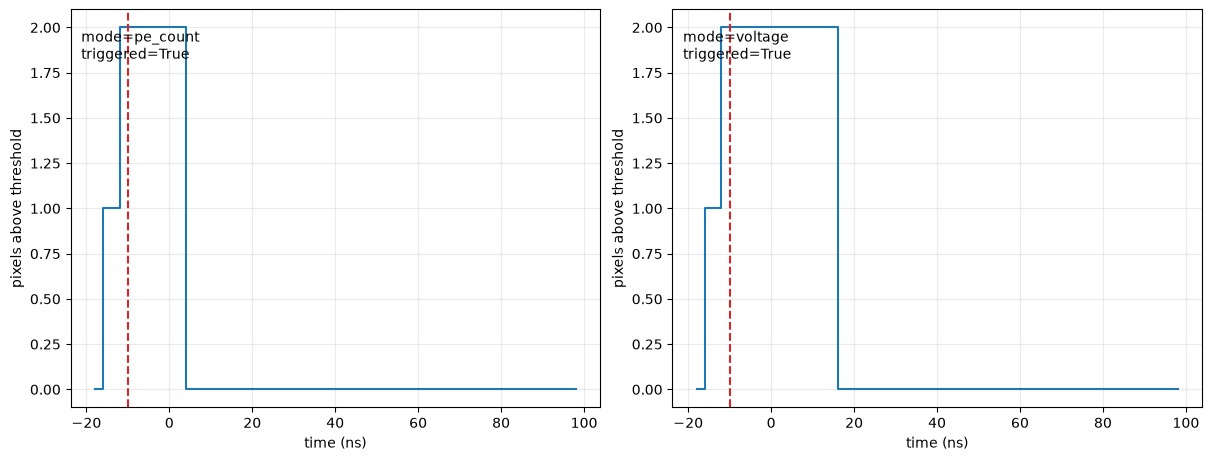

In [19]:
# 本 Cell：使用电子学模块的独立小测试，比较 p.e. 阈值触发和电压阈值触发；不使用 event 1909。
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, name in zip(axes, ['pe_trigger', 'voltage_trigger']):
    folder = STANDALONE_ROOT / name
    trig = pd.read_csv(folder / 'trigger.csv').iloc[0]
    mult = pd.read_csv(folder / 'trigger_multiplicity.csv')
    ax.step(mult.time_center_ns, mult.pixels_above_threshold, where='mid')
    ax.axvline(trig.trigger_time_ns, ls='--', color=LOST_COLOR)
    ax.set_xlabel('time (ns)'); ax.set_ylabel('pixels above threshold'); ax.grid(alpha=.25)
    ax.text(.02, .95, f'mode={trig["mode"]}\ntriggered={bool(trig["triggered"])}', transform=ax.transAxes, va='top')
plt.show()

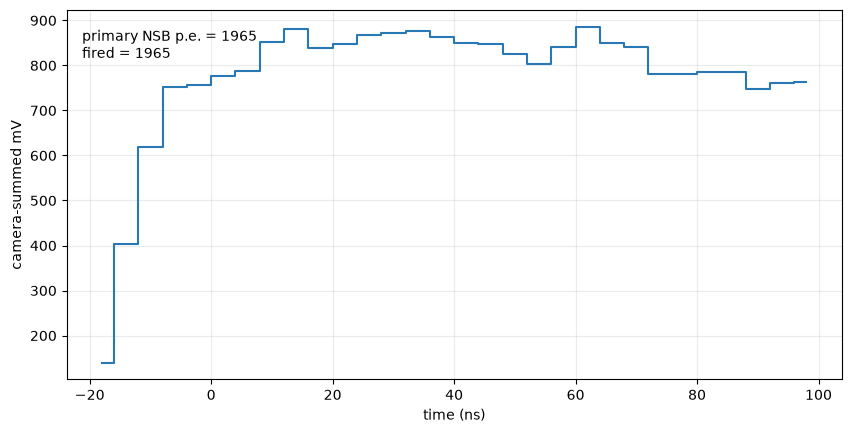

In [20]:
# 本 Cell：读取电子学模块独立生成的纯 NSB 波形，验证它可在簇射之外单独运行和叠加。
nsb_folder = STANDALONE_ROOT / 'nsb_only'
nsb_meta = json.loads((nsb_folder / 'metadata.json').read_text())
nsb_wave = pd.read_csv(nsb_folder / 'waveform.csv')
camera_nsb = nsb_wave.groupby('time_center_ns', as_index=False).sample_value.sum()
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.step(camera_nsb.time_center_ns, camera_nsb.sample_value, where='mid', color=PRIMARY_COLOR)
ax.set_xlabel('time (ns)'); ax.set_ylabel(f'camera-summed {nsb_meta["sample_unit"]}'); ax.grid(alpha=.25)
ax.text(.02, .95, f'primary NSB p.e. = {nsb_meta["n_primary_hits"]}\nfired = {nsb_meta["n_fired_hits"]}', transform=ax.transAxes, va='top')
plt.show()

In [21]:
# 本 Cell：汇总并断言关键机器检查项，包括 1664 像素、饱和单调性、4 ns 采样和 mV 单位。
all_primary = float(sum(np.sum(np.asarray(v)) for v in observations.image_cherenkov_pe))
all_fired = float(sum(np.sum(np.asarray(v)) for v in observations.image_fired_cherenkov_pe))
summary = pd.DataFrame({
    'check': ['camera pixels', 'gamma telescopes', 'primary Cherenkov p.e.', 'fired Cherenkov p.e.', 'saturation loss', 'nonzero waveform samples', 'sample width (ns)', 'sample unit'],
    'value': [len(camera['pixel_id']), len(observations), all_primary, all_fired, all_primary-all_fired, sum(len(v) for v in waveforms.sample_value), float(waveform_cfg.time_bin_width_ns[0]), str(waveform_cfg.sample_unit[0])]
})
assert len(camera['pixel_id']) == 1664
assert all_fired <= all_primary
assert float(waveform_cfg.time_bin_width_ns[0]) == 4.0
assert str(waveform_cfg.sample_unit[0]) == 'mV'
summary

,check,value
0,camera pixels,1664
1,gamma telescopes,32
2,primary Cherenkov p.e.,12372.0
3,fired Cherenkov p.e.,12367.0
4,saturation loss,5.0
5,nonzero waveform samples,28647
6,sample width (ns),4.0
7,sample unit,mV
